# CSI motion detection on `wifi_data_set_fixed`

In [20]:
from pathlib import Path
import os
import re
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "tools" / "csi_parser.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()

os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".matplotlib-cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from tools.wifi_data_preprocess import PreprocessConfig, motion_energy, preprocess_amplitude, robust_zscore
from tools.csi_parser import Parser

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["image.aspect"] = "auto"
np.set_printoptions(suppress=True, linewidth=120)

DATASET_ROOT = PROJECT_ROOT / "wifi_data_set_fixed"
if not DATASET_ROOT.exists():
    raise FileNotFoundError(f"Не найден DATASET_ROOT={DATASET_ROOT}")

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATASET_ROOT =", DATASET_ROOT)

PROJECT_ROOT = /home/LijnxArcher/CSI-activity-detection
DATASET_ROOT = /home/LijnxArcher/CSI-activity-detection/wifi_data_set_fixed


## Experiment Settings

In [21]:
DEVICE_ORDER = ("dev1", "dev2", "dev3")

# label_00 -> no motion; label_01..03 -> motion at distance 1..3 m.
NO_MOTION_LABEL = "label_00"
MOTION_LABELS = ("label_01", "label_02", "label_03")
LABEL_TO_DISTANCE_M = {
    "label_00": 0,
    "label_01": 1,
    "label_02": 2,
    "label_03": 3,
}

PREPROCESS_CONFIG = PreprocessConfig(
    pipeline="hampel_savgol",  # "none", "median", "hampel_savgol"
    apply_detrend=False,
    apply_zscore=False,
    hampel_window=7,
    hampel_sigma=3.0,
    sg_window=11,
    sg_poly=3,
    median_window=7,
    detrend_window=51,
    scale_floor_percentile=10.0,
    z_clip=8.0,
)

# Every fixed recording currently has 100 packets per receiver.
ML_WINDOW = 100
ML_STEP = 100

# Balance binary classes by default: all no-motion recordings and the same number
# of motion recordings sampled round-robin from label_01/02/03.
BALANCE_BINARY_CLASSES = True
ML_MAX_RECORDINGS_PER_BINARY_CLASS = None

# "motion_only" is the most honest starting point for movement detection.
# Use "all" for diagnostics or "absolute_only" to see how much baseline leakage helps.
FEATURE_SET = "motion_only"  # "motion_only", "absolute_only", "all"

# "recording_id" prevents windows from the same test folder from leaking across split.
# "person" is stricter and estimates generalization to unseen people, but only has 4 groups.
SPLIT_GROUP = "recording_id"  # "recording_id" or "person"
RANDOM_STATE = 42

print(PREPROCESS_CONFIG)

PreprocessConfig(pipeline='hampel_savgol', apply_detrend=False, apply_zscore=False, hampel_window=7, hampel_sigma=3.0, sg_window=11, sg_poly=3, median_window=7, detrend_window=51, scale_floor_percentile=10.0, z_clip=8.0)


## Dataset Index

Одна строка индекса соответствует папке `test_*`, то есть одной записи с тремя приёмниками.

In [22]:
DEVICE_RE = re.compile(r"__(dev\d+)_")
TEST_RE = re.compile(r"test_(\d+)$")


def natural_test_key(path: Path) -> tuple[int, str]:
    match = TEST_RE.search(path.name)
    return (int(match.group(1)) if match else 10**9, path.name)


def device_name_from_path(path: Path) -> str:
    match = DEVICE_RE.search(path.name)
    if not match:
        raise ValueError(f"Cannot infer device name from {path.name}")
    return match.group(1)


def build_recording_index(dataset_root: Path = DATASET_ROOT) -> pd.DataFrame:
    rows = []

    for person_dir in sorted(dataset_root.glob("id_person_*")):
        if not person_dir.is_dir():
            continue
        for label_dir in sorted(person_dir.glob("label_*")):
            if not label_dir.is_dir():
                continue
            for test_dir in sorted(label_dir.glob("test_*"), key=natural_test_key):
                if not test_dir.is_dir():
                    continue

                files_by_device = {}
                for path in sorted(test_dir.glob("*.data")):
                    files_by_device[device_name_from_path(path)] = path

                missing = [dev for dev in DEVICE_ORDER if dev not in files_by_device]
                label_name = label_dir.name
                distance_m = LABEL_TO_DISTANCE_M.get(label_name)
                binary_label = 0 if label_name == NO_MOTION_LABEL else 1

                row = {
                    "recording_id": str(test_dir.relative_to(dataset_root)),
                    "person": person_dir.name,
                    "source_label": label_name,
                    "binary_label": binary_label,
                    "binary_name": "no_motion" if binary_label == 0 else "motion",
                    "distance_m": distance_m,
                    "test": test_dir.name,
                    "test_dir": test_dir,
                    "n_devices": len(files_by_device),
                    "missing_devices": ",".join(missing),
                }
                for dev in DEVICE_ORDER:
                    row[f"{dev}_path"] = files_by_device.get(dev)
                rows.append(row)

    index = pd.DataFrame(rows)
    if index.empty:
        raise ValueError(f"No recordings found in {dataset_root}")
    return index


recordings_df = build_recording_index()

print("Recordings:", len(recordings_df))
print("Files:", int(recordings_df["n_devices"].sum()))
print("Missing device rows:", int((recordings_df["missing_devices"] != "").sum()))
print("\nBy person/label:")
display(recordings_df.groupby(["person", "source_label"]).size().unstack(fill_value=0))
print("\nBinary balance:")
display(recordings_df["binary_name"].value_counts())
recordings_df.head()

Recordings: 1600
Files: 4800
Missing device rows: 0

By person/label:


source_label,label_00,label_01,label_02,label_03
person,,,,
id_person_01,100,100,100,100
id_person_02,100,100,100,100
id_person_03,100,100,100,100
id_person_04,100,100,100,100



Binary balance:


binary_name
motion       1200
no_motion     400
Name: count, dtype: int64

,recording_id,person,source_label,binary_label,binary_name,distance_m,test,test_dir,n_devices,missing_devices,dev1_path,dev2_path,dev3_path
0,id_person_01/label_00/test_01,id_person_01,label_00,0,no_motion,0,test_01,/home/LijnxArcher/CSI-activity-detection/wifi_...,3,,/home/LijnxArcher/CSI-activity-detection/wifi_...,/home/LijnxArcher/CSI-activity-detection/wifi_...,/home/LijnxArcher/CSI-activity-detection/wifi_...
1,id_person_01/label_00/test_02,id_person_01,label_00,0,no_motion,0,test_02,/home/LijnxArcher/CSI-activity-detection/wifi_...,3,,/home/LijnxArcher/CSI-activity-detection/wifi_...,/home/LijnxArcher/CSI-activity-detection/wifi_...,/home/LijnxArcher/CSI-activity-detection/wifi_...
2,id_person_01/label_00/test_03,id_person_01,label_00,0,no_motion,0,test_03,/home/LijnxArcher/CSI-activity-detection/wifi_...,3,,/home/LijnxArcher/CSI-activity-detection/wifi_...,/home/LijnxArcher/CSI-activity-detection/wifi_...,/home/LijnxArcher/CSI-activity-detection/wifi_...
3,id_person_01/label_00/test_04,id_person_01,label_00,0,no_motion,0,test_04,/home/LijnxArcher/CSI-activity-detection/wifi_...,3,,/home/LijnxArcher/CSI-activity-detection/wifi_...,/home/LijnxArcher/CSI-activity-detection/wifi_...,/home/LijnxArcher/CSI-activity-detection/wifi_...
4,id_person_01/label_00/test_05,id_person_01,label_00,0,no_motion,0,test_05,/home/LijnxArcher/CSI-activity-detection/wifi_...,3,,/home/LijnxArcher/CSI-activity-detection/wifi_...,/home/LijnxArcher/CSI-activity-detection/wifi_...,/home/LijnxArcher/CSI-activity-detection/wifi_...


## CSI Parser And Null Subcarriers

Новый датасет содержит 128 raw IQ-значений на packet. `tools.csi_parser.Parser` переводит их в 64 комплексные поднесущие и amplitude. Постоянно нулевые amplitude-поднесущие выводятся из данных автоматически.

In [23]:
def parse_amplitude_file(path: Path) -> tuple[np.ndarray, pd.DataFrame]:
    """Parse one fixed ESP32-S3 file using tools.csi_parser.Parser."""

    df = Parser(path).parse()
    amplitude = np.stack(df["amplitude"].to_numpy()).astype(np.float32)
    return amplitude, df


def infer_null_subcarriers(
    recordings: pd.DataFrame,
    sample_per_label: int = 4,
    zero_ratio_threshold: float = 0.99,
) -> list[int]:
    """Infer subcarrier indexes that are zero in almost every sampled packet."""

    sample_rows = []
    for label, group in recordings.groupby("source_label", sort=True):
        sample_rows.append(group.head(sample_per_label))
    sample = pd.concat(sample_rows, ignore_index=True)

    zero_counts = None
    total_packets = 0
    subcarrier_count = None

    for _, row in sample.iterrows():
        for dev in DEVICE_ORDER:
            amplitude, _ = parse_amplitude_file(row[f"{dev}_path"])
            if subcarrier_count is None:
                subcarrier_count = amplitude.shape[1]
            elif amplitude.shape[1] != subcarrier_count:
                raise ValueError("Inconsistent subcarrier count while inferring null subcarriers")

            zeros = np.isclose(amplitude, 0.0).sum(axis=0)
            zero_counts = zeros if zero_counts is None else zero_counts + zeros
            total_packets += amplitude.shape[0]

    zero_ratio = zero_counts / max(total_packets, 1)
    null_idx = np.flatnonzero(zero_ratio >= zero_ratio_threshold).astype(int).tolist()
    return null_idx


NULL_SUBCARRIERS = infer_null_subcarriers(recordings_df)
VALID_SUBCARRIERS = [i for i in range(64) if i not in NULL_SUBCARRIERS]

print("NULL_SUBCARRIERS =", NULL_SUBCARRIERS)
print("Valid subcarriers:", len(VALID_SUBCARRIERS), "of 64")

NULL_SUBCARRIERS = [0, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]
Valid subcarriers: 52 of 64


In [24]:
def remove_null_subcarriers(amplitude: np.ndarray, null_subcarriers: list[int] | tuple[int, ...]) -> np.ndarray:
    if not null_subcarriers:
        return np.asarray(amplitude, dtype=np.float32)
    return np.delete(np.asarray(amplitude, dtype=np.float32), null_subcarriers, axis=-1)


def load_recording(row: pd.Series, null_subcarriers: list[int] | tuple[int, ...] = NULL_SUBCARRIERS) -> dict:
    """Load one test folder as [T, D, S] amplitude plus aligned RSSI metadata."""

    amplitudes = []
    rssi_values = []
    packet_seq_values = []
    local_timestamp_values = []

    for dev in DEVICE_ORDER:
        amplitude, df = parse_amplitude_file(row[f"{dev}_path"])
        amplitude = remove_null_subcarriers(amplitude, null_subcarriers)

        amplitudes.append(amplitude)
        rssi_values.append(df["rssi_dbm"].to_numpy(dtype=np.float32))
        packet_seq_values.append(df["packet_seq"].to_numpy(dtype=np.int64))
        local_timestamp_values.append(df["local_timestamp"].astype(np.int64).to_numpy())

    min_len = min(x.shape[0] for x in amplitudes)
    amplitudes = [x[:min_len] for x in amplitudes]
    rssi_values = [x[:min_len] for x in rssi_values]
    packet_seq_values = [x[:min_len] for x in packet_seq_values]
    local_timestamp_values = [x[:min_len] for x in local_timestamp_values]

    return {
        "amplitude": np.stack(amplitudes, axis=1).astype(np.float32),  # [T, D, S]
        "rssi": np.stack(rssi_values, axis=1).astype(np.float32),       # [T, D]
        "packet_seq": np.stack(packet_seq_values, axis=1),
        "local_timestamp": np.stack(local_timestamp_values, axis=1),
        "device_names": DEVICE_ORDER,
        "recording_id": row["recording_id"],
        "person": row["person"],
        "source_label": row["source_label"],
        "binary_label": int(row["binary_label"]),
        "distance_m": int(row["distance_m"]),
    }


example_static_row = recordings_df.query("source_label == 'label_00'").iloc[0]
example_motion_row = recordings_df.query("source_label == 'label_01'").iloc[0]

example_static = load_recording(example_static_row)
example_motion = load_recording(example_motion_row)

print("Static amplitude shape [T, D, S]:", example_static["amplitude"].shape)
print("Motion amplitude shape [T, D, S]:", example_motion["amplitude"].shape)
print("Devices:", example_static["device_names"])

Static amplitude shape [T, D, S]: (100, 3, 52)
Motion amplitude shape [T, D, S]: (100, 3, 52)
Devices: ('dev1', 'dev2', 'dev3')


## Quick Visualization

Heatmap строится отдельно для каждого приёмника, чтобы не схлопывать пространственную информацию слишком рано.

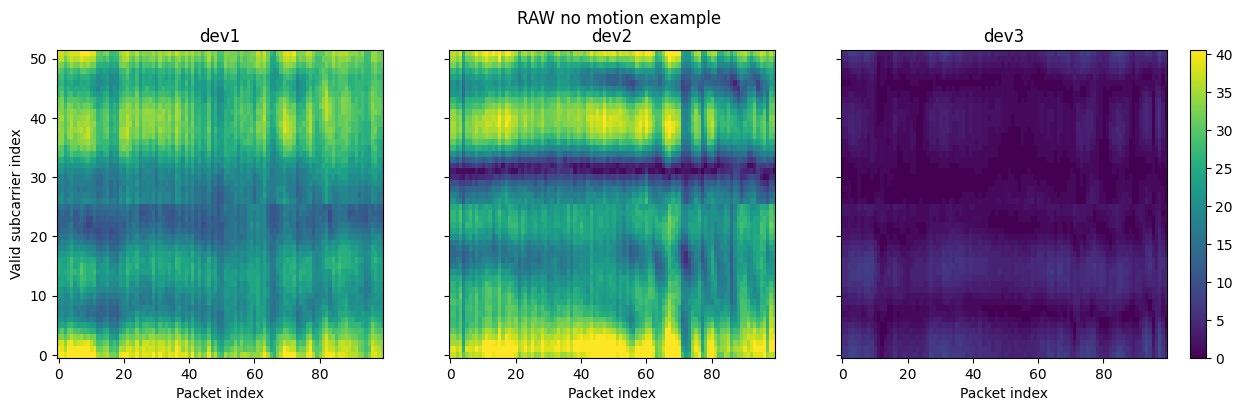

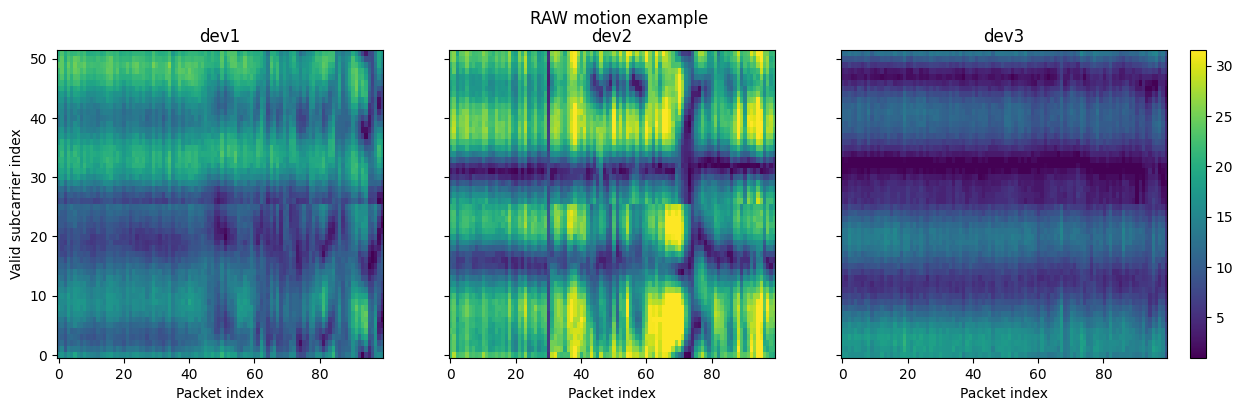

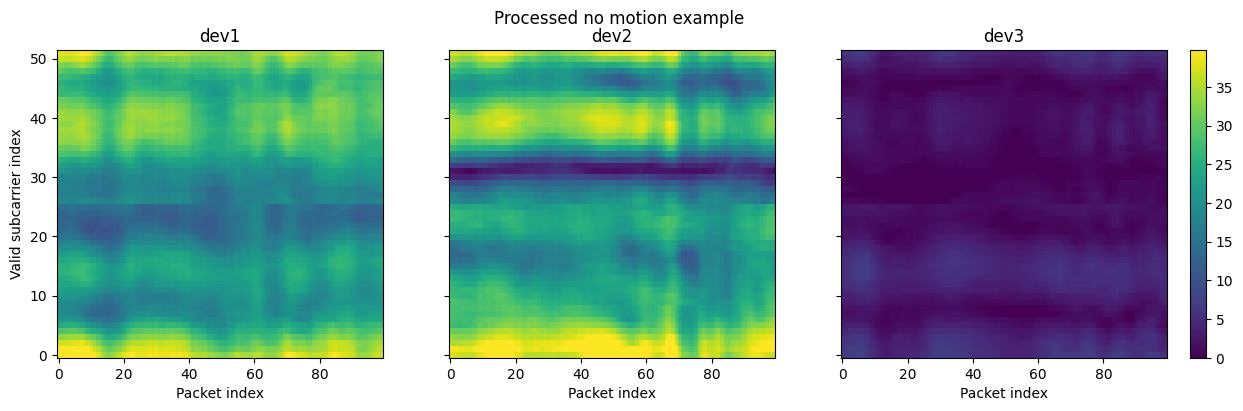

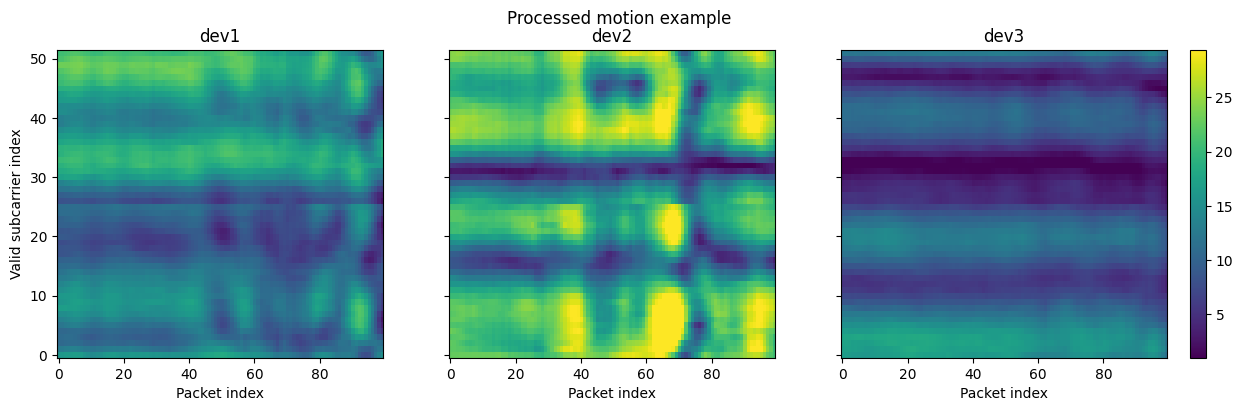

In [25]:
def robust_color_limits(X, q: float = 99.0, center_zero: bool = False):
    X = np.asarray(X, dtype=np.float32)
    finite = X[np.isfinite(X)]
    if finite.size == 0:
        return None, None

    if center_zero:
        lim = np.nanpercentile(np.abs(finite), q)
        lim = max(float(lim), 1e-6)
        return -lim, lim

    lo, hi = np.nanpercentile(finite, [100 - q, q])
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        return None, None
    return float(lo), float(hi)


def plot_receiver_heatmaps(X, title: str, device_names=DEVICE_ORDER, max_packets: int = 100, center_zero: bool = False):
    """Plot [T, D, S] as one heatmap per receiver."""

    T = min(max_packets, X.shape[0])
    fig, axes = plt.subplots(1, X.shape[1], figsize=(15, 4), sharey=True)
    if X.shape[1] == 1:
        axes = [axes]

    vmin, vmax = robust_color_limits(X[:T], center_zero=center_zero)
    cmap = "coolwarm" if center_zero else "viridis"

    for dev_i, ax in enumerate(axes):
        image = ax.imshow(
            X[:T, dev_i, :].T,
            origin="lower",
            aspect="auto",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title(device_names[dev_i])
        ax.set_xlabel("Packet index")
        if dev_i == 0:
            ax.set_ylabel("Valid subcarrier index")

    fig.colorbar(image, ax=axes, fraction=0.025, pad=0.02)
    fig.suptitle(title)
    plt.show()


static_proc = preprocess_amplitude(example_static["amplitude"], PREPROCESS_CONFIG)
motion_proc = preprocess_amplitude(example_motion["amplitude"], PREPROCESS_CONFIG)

plot_receiver_heatmaps(example_static["amplitude"], "RAW no motion example")
plot_receiver_heatmaps(example_motion["amplitude"], "RAW motion example")
plot_receiver_heatmaps(static_proc["normalized"], "Processed no motion example", center_zero=PREPROCESS_CONFIG.apply_zscore)
plot_receiver_heatmaps(motion_proc["normalized"], "Processed motion example", center_zero=PREPROCESS_CONFIG.apply_zscore)

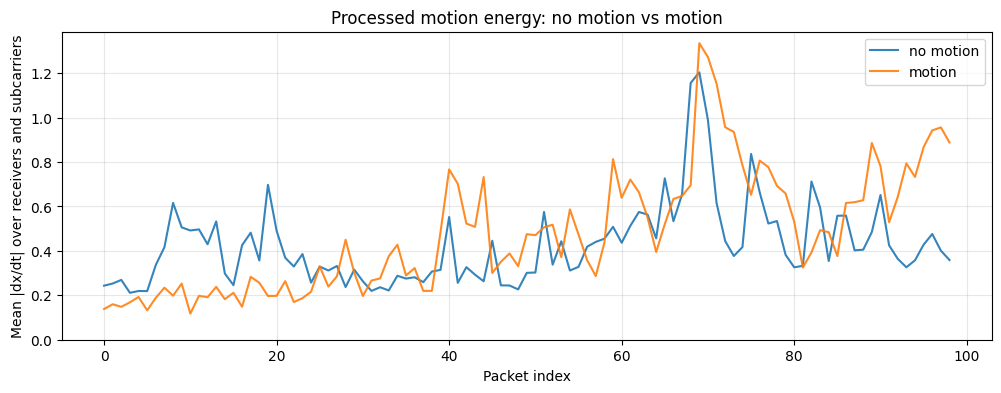

In [26]:
def plot_motion_energy_comparison(static_X: np.ndarray, motion_X: np.ndarray, title: str = "Motion energy"):
    e_static = motion_energy(static_X)
    e_motion = motion_energy(motion_X)
    ymax = np.percentile(np.r_[e_static, e_motion], 99)
    ymax = max(float(ymax) * 1.15, 1e-6)

    plt.figure(figsize=(12, 4))
    plt.plot(e_static, label="no motion", alpha=0.9)
    plt.plot(e_motion, label="motion", alpha=0.9)
    plt.title(title)
    plt.xlabel("Packet index")
    plt.ylabel("Mean |dx/dt| over receivers and subcarriers")
    plt.ylim(0, ymax)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


plot_motion_energy_comparison(
    static_proc["normalized"],
    motion_proc["normalized"],
    title="Processed motion energy: no motion vs motion",
)

## Build Binary Windows

Для текущей задачи `label_00` получает `y=0`, а `label_01/02/03` получают `y=1`. При этом `distance_m` сохраняется в metadata для будущей многоклассовой постановки.

In [27]:
def round_robin_sample_by_column(
    df: pd.DataFrame,
    column: str,
    n: int | None,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    if n is None or len(df) <= n:
        return df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)

    rng = np.random.default_rng(random_state)
    groups = []
    for _, group in df.groupby(column, sort=True):
        order = rng.permutation(len(group))
        groups.append(group.iloc[order].reset_index(drop=True))

    selected_rows = []
    cursors = [0] * len(groups)
    while len(selected_rows) < n:
        added = False
        for group_i, group in enumerate(groups):
            cursor = cursors[group_i]
            if cursor < len(group) and len(selected_rows) < n:
                selected_rows.append(group.iloc[cursor])
                cursors[group_i] += 1
                added = True
        if not added:
            break

    return pd.DataFrame(selected_rows).reset_index(drop=True)


def select_recordings_for_binary_task(
    recordings: pd.DataFrame,
    balance_binary_classes: bool = BALANCE_BINARY_CLASSES,
    max_per_binary_class: int | None = ML_MAX_RECORDINGS_PER_BINARY_CLASS,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    counts = recordings["binary_label"].value_counts().sort_index()
    if balance_binary_classes:
        target = int(counts.min())
    else:
        target = None

    if max_per_binary_class is not None:
        target = max_per_binary_class if target is None else min(target, max_per_binary_class)

    selected = []
    for binary_label, group in recordings.groupby("binary_label", sort=True):
        selected.append(
            round_robin_sample_by_column(
                group,
                column="source_label",
                n=target,
                random_state=random_state + int(binary_label),
            )
        )

    return pd.concat(selected, ignore_index=True).sample(frac=1.0, random_state=random_state).reset_index(drop=True)


def segment_array(X: np.ndarray, window: int = ML_WINDOW, step: int = ML_STEP) -> list[np.ndarray]:
    if len(X) < window:
        return []
    return [X[start:start + window] for start in range(0, len(X) - window + 1, step)]


def build_binary_windows(
    recordings: pd.DataFrame,
    preprocess_config: PreprocessConfig = PREPROCESS_CONFIG,
    window: int = ML_WINDOW,
    step: int = ML_STEP,
    random_state: int = RANDOM_STATE,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, pd.DataFrame, np.ndarray]:
    X_list = []
    rssi_list = []
    y_list = []
    meta_rows = []

    selected = select_recordings_for_binary_task(recordings, random_state=random_state)

    for i, row in selected.iterrows():
        try:
            rec = load_recording(row)
            proc = preprocess_amplitude(rec["amplitude"], preprocess_config)
            X_proc = proc["normalized"]
            X_segments = segment_array(X_proc, window=window, step=step)
            rssi_segments = segment_array(rec["rssi"], window=window, step=step)

            for segment_i, (x_seg, rssi_seg) in enumerate(zip(X_segments, rssi_segments)):
                X_list.append(x_seg.astype(np.float32))
                rssi_list.append(rssi_seg.astype(np.float32))
                y_list.append(rec["binary_label"])
                meta_rows.append({
                    "recording_id": rec["recording_id"],
                    "segment": segment_i,
                    "person": rec["person"],
                    "source_label": rec["source_label"],
                    "binary_label": rec["binary_label"],
                    "binary_name": "no_motion" if rec["binary_label"] == 0 else "motion",
                    "distance_m": rec["distance_m"],
                    "n_packets": x_seg.shape[0],
                    "n_devices": x_seg.shape[1],
                    "n_subcarriers": x_seg.shape[2],
                })
        except Exception as exc:
            print(f"Skip {row['recording_id']}: {exc}")

    if not X_list:
        raise ValueError("No windows were built. Check parser, window length, and dataset path.")

    X = np.stack(X_list).astype(np.float32)          # [N, T, D, S]
    rssi = np.stack(rssi_list).astype(np.float32)    # [N, T, D]
    y = np.asarray(y_list, dtype=np.int64)
    metadata = pd.DataFrame(meta_rows)
    groups = metadata[SPLIT_GROUP].astype(str).to_numpy()
    return X, y, groups, metadata, rssi


X_bin, y_bin, groups_bin, metadata_bin, rssi_bin = build_binary_windows(recordings_df)

print("X [N, T, D, S]:", X_bin.shape)
print("RSSI [N, T, D]:", rssi_bin.shape)
print("y:", y_bin.shape)
print("Binary balance [no_motion, motion]:", np.bincount(y_bin, minlength=2))
print("Groups:", SPLIT_GROUP, len(np.unique(groups_bin)))
print("\nWindows by source label:")
display(metadata_bin["source_label"].value_counts().sort_index())
print("\nWindows by person/source label:")
display(metadata_bin.groupby(["person", "source_label"]).size().unstack(fill_value=0))

X [N, T, D, S]: (800, 100, 3, 52)
RSSI [N, T, D]: (800, 100, 3)
y: (800,)
Binary balance [no_motion, motion]: [400 400]
Groups: recording_id 800

Windows by source label:


source_label
label_00    400
label_01    134
label_02    133
label_03    133
Name: count, dtype: int64


Windows by person/source label:


source_label,label_00,label_01,label_02,label_03
person,,,,
id_person_01,100,41,29,35
id_person_02,100,30,34,36
id_person_03,100,35,37,31
id_person_04,100,28,33,31


## Feature Extraction

Признаки остаются классическими табличными: статистики по окну, энергия изменений во времени, per-subcarrier энергия и per-time профиль. Информация с каждого приёмника сохраняется отдельными признаками `dev1/dev2/dev3`, плюс добавлены простые cross-device признаки.

In [28]:
def summarize_vector(v, prefix: str) -> dict[str, float]:
    v = np.asarray(v, dtype=np.float32)
    if v.size == 0:
        return {
            f"{prefix}_mean": 0.0,
            f"{prefix}_std": 0.0,
            f"{prefix}_min": 0.0,
            f"{prefix}_p10": 0.0,
            f"{prefix}_median": 0.0,
            f"{prefix}_p90": 0.0,
            f"{prefix}_max": 0.0,
        }

    return {
        f"{prefix}_mean": float(np.mean(v)),
        f"{prefix}_std": float(np.std(v)),
        f"{prefix}_min": float(np.min(v)),
        f"{prefix}_p10": float(np.percentile(v, 10)),
        f"{prefix}_median": float(np.median(v)),
        f"{prefix}_p90": float(np.percentile(v, 90)),
        f"{prefix}_max": float(np.max(v)),
    }


def add_sequence_features(feats: dict[str, float], values: np.ndarray, prefix: str) -> None:
    for i, value in enumerate(np.asarray(values, dtype=np.float32)):
        feats[f"{prefix}_{i:03d}"] = float(value)


def extract_one_window_features(window: np.ndarray, rssi_window: np.ndarray, device_names=DEVICE_ORDER) -> dict[str, float]:
    """Extract features from one [T, D, S] CSI window."""

    feats = {}
    d_time = np.diff(window, axis=0)
    abs_d_time = np.abs(d_time)
    abs_window = np.abs(window)
    global_motion_e = np.mean(abs_d_time, axis=(1, 2))

    feats.update(summarize_vector(window.ravel(), "absolute__global_x"))
    feats.update(summarize_vector(abs_window.ravel(), "absolute__global_abs_x"))
    feats.update(summarize_vector(d_time.ravel(), "motion__global_dt"))
    feats.update(summarize_vector(abs_d_time.ravel(), "motion__global_abs_dt"))
    feats.update(summarize_vector(global_motion_e, "motion__global_motion_energy"))

    receiver_spread = np.std(window, axis=1)  # [T, S], spread across dev1/dev2/dev3
    feats.update(summarize_vector(receiver_spread.ravel(), "absolute__receiver_spread"))

    for dev_i, dev in enumerate(device_names):
        W = window[:, dev_i, :]
        dW = np.diff(W, axis=0)
        abs_dW = np.abs(dW)
        e_t = np.mean(abs_dW, axis=1)

        feats.update(summarize_vector(W.ravel(), f"absolute__{dev}_x"))
        feats.update(summarize_vector(np.abs(W).ravel(), f"absolute__{dev}_abs_x"))
        feats.update(summarize_vector(dW.ravel(), f"motion__{dev}_dt"))
        feats.update(summarize_vector(abs_dW.ravel(), f"motion__{dev}_abs_dt"))
        feats.update(summarize_vector(e_t, f"motion__{dev}_motion_energy"))

        add_sequence_features(feats, np.mean(W, axis=0), f"absolute__{dev}_sc_mean")
        add_sequence_features(feats, np.std(W, axis=0), f"absolute__{dev}_sc_std")
        add_sequence_features(feats, np.mean(abs_dW, axis=0), f"motion__{dev}_sc_energy")
        add_sequence_features(feats, np.mean(W, axis=1), f"absolute__{dev}_t_mean")
        add_sequence_features(feats, np.r_[e_t, e_t[-1] if len(e_t) else 0.0], f"motion__{dev}_t_energy")

        rssi = rssi_window[:, dev_i]
        rssi_dt = np.diff(rssi)
        feats.update(summarize_vector(rssi, f"absolute__{dev}_rssi"))
        feats.update(summarize_vector(rssi_dt, f"motion__{dev}_rssi_dt"))

    for left_i in range(len(device_names)):
        for right_i in range(left_i + 1, len(device_names)):
            left = device_names[left_i]
            right = device_names[right_i]
            pair_absdiff = np.abs(window[:, left_i, :] - window[:, right_i, :])
            pair_absdiff_dt = np.abs(np.diff(pair_absdiff, axis=0))
            feats.update(summarize_vector(pair_absdiff.ravel(), f"absolute__pair_{left}_{right}_absdiff"))
            feats.update(summarize_vector(pair_absdiff_dt.ravel(), f"motion__pair_{left}_{right}_absdiff_dt"))

    return feats


def extract_csi_features(X: np.ndarray, rssi: np.ndarray) -> pd.DataFrame:
    rows = [extract_one_window_features(window, rssi_window) for window, rssi_window in zip(X, rssi)]
    return pd.DataFrame(rows).astype(np.float32)


def select_feature_columns(features: pd.DataFrame, feature_set: str = FEATURE_SET) -> list[str]:
    if feature_set == "all":
        return list(features.columns)
    if feature_set == "motion_only":
        cols = [c for c in features.columns if c.startswith("motion__")]
    elif feature_set == "absolute_only":
        cols = [c for c in features.columns if c.startswith("absolute__")]
    else:
        raise ValueError("Unknown FEATURE_SET. Use 'motion_only', 'absolute_only', or 'all'.")

    if not cols:
        raise ValueError(f"FEATURE_SET={feature_set!r} selected zero columns.")
    return cols


features_all = extract_csi_features(X_bin, rssi_bin)
selected_feature_columns = select_feature_columns(features_all, FEATURE_SET)
features_ml = features_all[selected_feature_columns]

print("Feature table, all:", features_all.shape)
print(f"FEATURE_SET = {FEATURE_SET!r}")
print("Feature table, selected:", features_ml.shape)
display(features_ml.head())

Feature table, all: (800, 1299)
FEATURE_SET = 'motion_only'
Feature table, selected: (800, 582)


,motion__global_dt_mean,motion__global_dt_std,motion__global_dt_min,motion__global_dt_p10,motion__global_dt_median,motion__global_dt_p90,motion__global_dt_max,motion__global_abs_dt_mean,motion__global_abs_dt_std,motion__global_abs_dt_min,...,motion__pair_dev1_dev3_absdiff_dt_median,motion__pair_dev1_dev3_absdiff_dt_p90,motion__pair_dev1_dev3_absdiff_dt_max,motion__pair_dev2_dev3_absdiff_dt_mean,motion__pair_dev2_dev3_absdiff_dt_std,motion__pair_dev2_dev3_absdiff_dt_min,motion__pair_dev2_dev3_absdiff_dt_p10,motion__pair_dev2_dev3_absdiff_dt_median,motion__pair_dev2_dev3_absdiff_dt_p90,motion__pair_dev2_dev3_absdiff_dt_max
0,0.061042,1.182480,-7.541443,-1.055628,0.027632,1.239600,8.516197,0.720414,0.939674,0.0,...,0.431198,1.590282,5.070750,1.348326,1.244500,0.001179,0.187189,1.001431,2.986656,8.644417
1,0.003007,1.151114,-10.253109,-0.979807,-0.011092,0.973621,9.887362,0.678351,0.930007,0.0,...,0.486108,1.342577,4.013434,1.272263,1.418765,0.000217,0.142579,0.841605,2.832748,11.145172
2,0.003178,0.360381,-1.845692,-0.446913,0.000000,0.442761,1.705904,0.247764,0.261720,0.0,...,0.304814,0.776928,1.817511,0.333343,0.256266,0.000056,0.052081,0.281481,0.693036,1.569872
3,-0.003564,1.044342,-5.775900,-1.253821,-0.006592,1.254325,5.142830,0.769037,0.706573,0.0,...,0.769346,2.108407,5.215014,1.149724,0.987252,0.001150,0.155399,0.904165,2.445531,6.875583
4,-0.005594,0.252128,-1.466377,-0.307076,0.000000,0.287425,1.389629,0.176964,0.179676,0.0,...,0.231882,0.583747,1.262060,0.205221,0.164681,0.000041,0.030956,0.169436,0.425714,1.343554


## Train/Test Split

Split делается группами. По умолчанию группа равна `recording_id`, поэтому окна одной и той же папки `test_*` не попадают одновременно в train и test.

In [29]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(features_ml, y_bin, groups=groups_bin))

X_train = features_ml.iloc[train_idx]
X_test = features_ml.iloc[test_idx]
y_train = y_bin[train_idx]
y_test = y_bin[test_idx]
meta_train = metadata_bin.iloc[train_idx].reset_index(drop=True)
meta_test = metadata_bin.iloc[test_idx].reset_index(drop=True)

groups_train = groups_bin[train_idx]
groups_test = groups_bin[test_idx]

print("Train windows:", X_train.shape[0], "Test windows:", X_test.shape[0])
print("Train groups:", len(np.unique(groups_train)), "Test groups:", len(np.unique(groups_test)))
print("Train balance [no_motion, motion]:", np.bincount(y_train, minlength=2))
print("Test balance  [no_motion, motion]:", np.bincount(y_test, minlength=2))
print("\nTest labels:")
display(meta_test["source_label"].value_counts().sort_index())
print("\nTest persons:")
display(meta_test["person"].value_counts().sort_index())

Train windows: 560 Test windows: 240
Train groups: 560 Test groups: 240
Train balance [no_motion, motion]: [283 277]
Test balance  [no_motion, motion]: [117 123]

Test labels:


source_label
label_00    117
label_01     47
label_02     38
label_03     38
Name: count, dtype: int64


Test persons:


person
id_person_01    63
id_person_02    62
id_person_03    53
id_person_04    62
Name: count, dtype: int64

In [30]:
models = {
    "dummy_most_frequent": DummyClassifier(strategy="most_frequent"),
    "logreg_balanced": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="liblinear",
            random_state=RANDOM_STATE,
        )),
    ]),
    "random_forest_balanced": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "svm_rbf_balanced": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            class_weight="balanced",
            probability=True,
            random_state=RANDOM_STATE,
        )),
    ]),
}

fitted_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    print("fit:", name)

fit: dummy_most_frequent
fit: logreg_balanced
fit: random_forest_balanced
fit: svm_rbf_balanced


In [31]:
def predict_positive_score(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        score = model.decision_function(X)
        return (score - score.min()) / (score.max() - score.min() + 1e-8)
    return None


def evaluate_model(name: str, model, X_test: pd.DataFrame, y_test: np.ndarray) -> dict[str, float | str]:
    y_pred = model.predict(X_test)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_test,
        y_pred,
        labels=[0, 1],
        zero_division=0,
    )
    score = predict_positive_score(model, X_test)
    auc = np.nan
    if score is not None and len(np.unique(y_test)) == 2:
        auc = roc_auc_score(y_test, score)

    return {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision_no_motion": precision[0],
        "recall_no_motion": recall[0],
        "f1_no_motion": f1[0],
        "precision_motion": precision[1],
        "recall_motion": recall[1],
        "f1_motion": f1[1],
        "roc_auc": auc,
        "support_no_motion": support[0],
        "support_motion": support[1],
    }


metrics_df = pd.DataFrame([
    evaluate_model(name, model, X_test, y_test)
    for name, model in fitted_models.items()
]).sort_values("balanced_accuracy", ascending=False)

display(metrics_df)

,model,accuracy,balanced_accuracy,precision_no_motion,recall_no_motion,f1_no_motion,precision_motion,recall_motion,f1_motion,roc_auc,support_no_motion,support_motion
1,logreg_balanced,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,117,123
3,svm_rbf_balanced,0.991667,0.991661,0.991453,0.991453,0.991453,0.991870,0.99187,0.991870,0.999931,117,123
2,random_forest_balanced,0.987500,0.987596,0.983051,0.991453,0.987234,0.991803,0.98374,0.987755,0.998958,117,123
0,dummy_most_frequent,0.487500,0.500000,0.487500,1.000000,0.655462,0.000000,0.00000,0.000000,0.500000,117,123


Best model: logreg_balanced
              precision    recall  f1-score   support

   no_motion       1.00      1.00      1.00       117
      motion       1.00      1.00      1.00       123

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



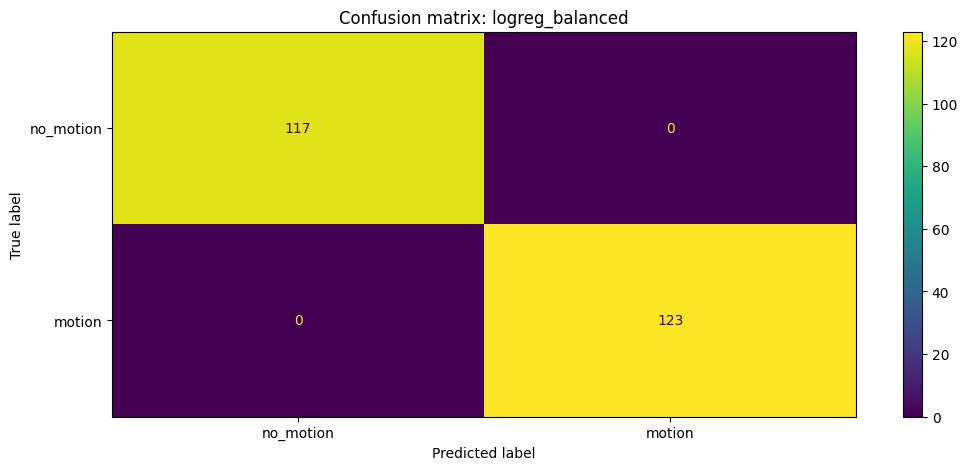

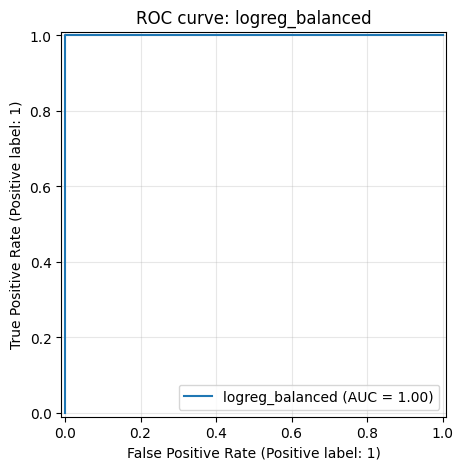

In [32]:
BEST_MODEL_NAME = metrics_df.iloc[0]["model"]
best_model = fitted_models[BEST_MODEL_NAME]
y_pred = best_model.predict(X_test)

print("Best model:", BEST_MODEL_NAME)
print(classification_report(
    y_test,
    y_pred,
    target_names=["no_motion", "motion"],
    zero_division=0,
))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
ConfusionMatrixDisplay(cm, display_labels=["no_motion", "motion"]).plot(values_format="d")
plt.title(f"Confusion matrix: {BEST_MODEL_NAME}")
plt.grid(False)
plt.show()

score = predict_positive_score(best_model, X_test)
if score is not None and len(np.unique(y_test)) == 2:
    RocCurveDisplay.from_predictions(y_test, score, name=BEST_MODEL_NAME)
    plt.title(f"ROC curve: {BEST_MODEL_NAME}")
    plt.grid(alpha=0.3)
    plt.show()

,feature,importance
382,motion__dev3_dt_std,0.046734
391,motion__dev3_abs_dt_p10,0.043695
389,motion__dev3_abs_dt_std,0.037275
432,motion__dev3_sc_energy_030,0.032368
388,motion__dev3_abs_dt_mean,0.028512
394,motion__dev3_abs_dt_max,0.027417
449,motion__dev3_sc_energy_047,0.027242
448,motion__dev3_sc_energy_046,0.026824
409,motion__dev3_sc_energy_007,0.024754
400,motion__dev3_motion_energy_p90,0.024249


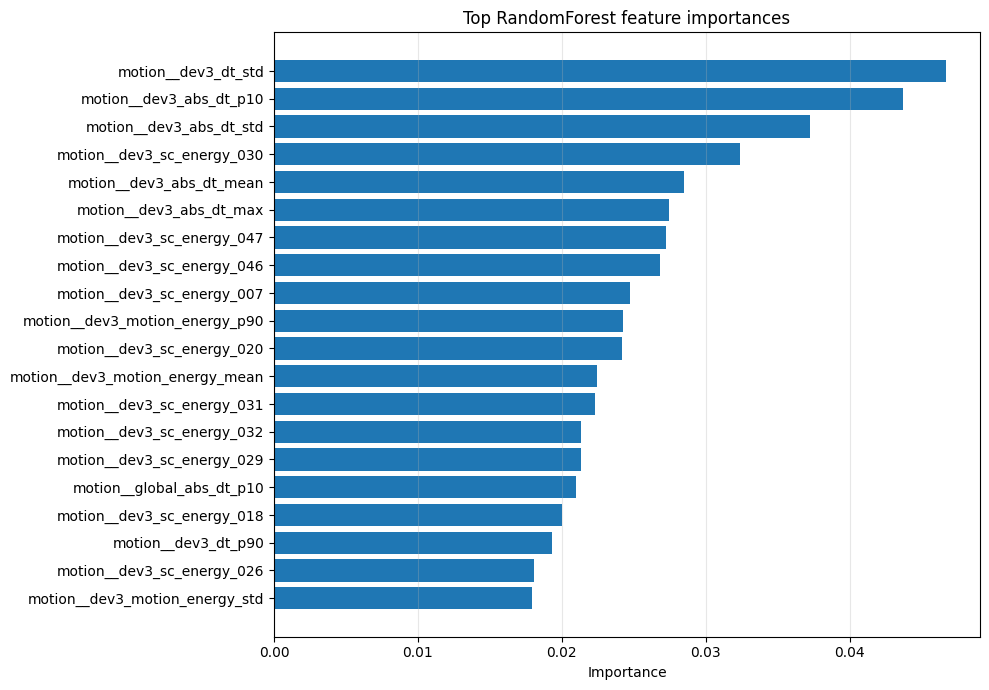

In [33]:
rf = fitted_models.get("random_forest_balanced")
if rf is not None and hasattr(rf, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": features_ml.columns,
        "importance": rf.feature_importances_,
    }).sort_values("importance", ascending=False)

    display(importance_df.head(30))

    top = importance_df.head(20).iloc[::-1]
    plt.figure(figsize=(10, 7))
    plt.barh(top["feature"], top["importance"])
    plt.title("Top RandomForest feature importances")
    plt.xlabel("Importance")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

## Binary Split Comparison

Здесь та же бинарная задача `no_motion / motion` оценивается при разных `split_group`. `recording_id` проверяет новые записи в похожих условиях, а `person` проверяет перенос на людей, которых модель не видела при обучении.

In [34]:
BINARY_SPLIT_GROUPS = ("recording_id", "person")


def make_binary_models() -> dict[str, object]:
    return {
        "dummy_most_frequent": DummyClassifier(strategy="most_frequent"),
        "logreg_balanced": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                solver="liblinear",
                random_state=RANDOM_STATE,
            )),
        ]),
        "random_forest_balanced": RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "svm_rbf_balanced": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(
                kernel="rbf",
                C=1.0,
                gamma="scale",
                class_weight="balanced",
                probability=True,
                random_state=RANDOM_STATE,
            )),
        ]),
    }


def run_binary_split(split_group: str) -> dict[str, object]:
    groups = metadata_bin[split_group].astype(str).to_numpy()
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
    train_idx, test_idx = next(splitter.split(features_ml, y_bin, groups=groups))

    X_train = features_ml.iloc[train_idx]
    X_test = features_ml.iloc[test_idx]
    y_train = y_bin[train_idx]
    y_test = y_bin[test_idx]
    meta_train = metadata_bin.iloc[train_idx].reset_index(drop=True)
    meta_test = metadata_bin.iloc[test_idx].reset_index(drop=True)

    fitted = {}
    metrics = []
    for name, model in make_binary_models().items():
        model.fit(X_train, y_train)
        fitted[name] = model
        metrics.append(evaluate_model(name, model, X_test, y_test))

    metrics_df = pd.DataFrame(metrics).sort_values("balanced_accuracy", ascending=False)
    return {
        "split_group": split_group,
        "train_idx": train_idx,
        "test_idx": test_idx,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "meta_train": meta_train,
        "meta_test": meta_test,
        "fitted_models": fitted,
        "metrics": metrics_df,
    }


binary_split_results = {split_group: run_binary_split(split_group) for split_group in BINARY_SPLIT_GROUPS}
binary_split_metrics_df = pd.concat(
    [result["metrics"].assign(split_group=split_group) for split_group, result in binary_split_results.items()],
    ignore_index=True,
)

binary_metric_cols = [
    "split_group",
    "model",
    "accuracy",
    "balanced_accuracy",
    "f1_no_motion",
    "f1_motion",
    "roc_auc",
    "support_no_motion",
    "support_motion",
]
display(binary_split_metrics_df[binary_metric_cols].sort_values(
    ["split_group", "balanced_accuracy"],
    ascending=[True, False],
))

,split_group,model,accuracy,balanced_accuracy,f1_no_motion,f1_motion,roc_auc,support_no_motion,support_motion
4,person,svm_rbf_balanced,0.961735,0.960938,0.963855,0.959350,0.999687,200,192
5,person,random_forest_balanced,0.938776,0.937500,0.943396,0.933333,0.999271,200,192
6,person,logreg_balanced,0.900510,0.898438,0.911162,0.886957,0.998281,200,192
7,person,dummy_most_frequent,0.489796,0.500000,0.000000,0.657534,0.500000,200,192
0,recording_id,logreg_balanced,1.000000,1.000000,1.000000,1.000000,1.000000,117,123
1,recording_id,svm_rbf_balanced,0.991667,0.991661,0.991453,0.991870,0.999931,117,123
2,recording_id,random_forest_balanced,0.987500,0.987596,0.987234,0.987755,0.998958,117,123
3,recording_id,dummy_most_frequent,0.487500,0.500000,0.655462,0.000000,0.500000,117,123


Binary split: recording_id
Best model: logreg_balanced
Train balance: {0: 283, 1: 277}
Test balance : {0: 117, 1: 123}
              precision    recall  f1-score   support

   no_motion       1.00      1.00      1.00       117
      motion       1.00      1.00      1.00       123

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



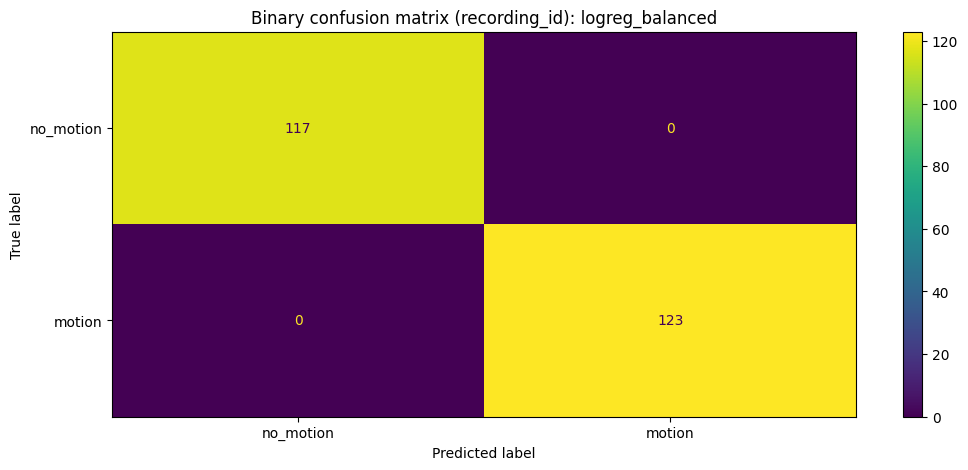

Binary split: person
Best model: svm_rbf_balanced
Train balance: {0: 200, 1: 208}
Test balance : {0: 200, 1: 192}
              precision    recall  f1-score   support

   no_motion       0.93      1.00      0.96       200
      motion       1.00      0.92      0.96       192

    accuracy                           0.96       392
   macro avg       0.97      0.96      0.96       392
weighted avg       0.96      0.96      0.96       392



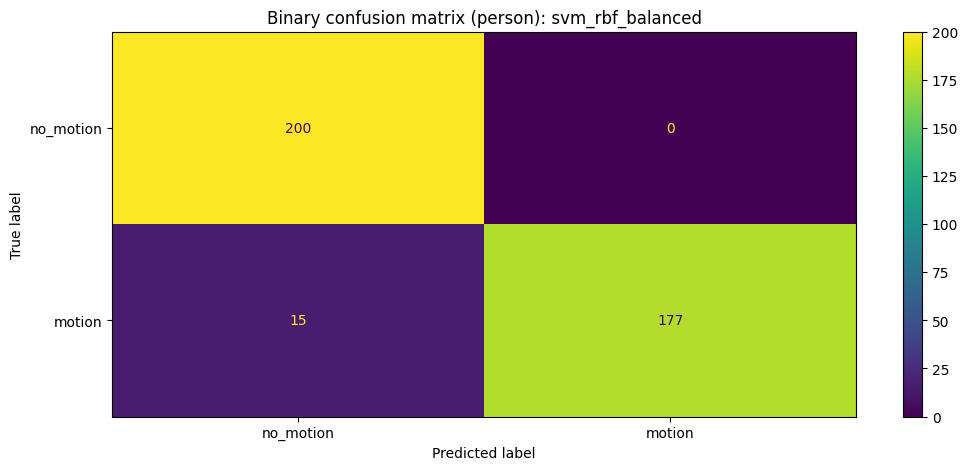

In [35]:
for split_group, result in binary_split_results.items():
    best_name = result["metrics"].iloc[0]["model"]
    best_model = result["fitted_models"][best_name]
    y_test = result["y_test"]
    y_pred = best_model.predict(result["X_test"])

    print("=" * 80)
    print(f"Binary split: {split_group}")
    print("Best model:", best_name)
    print("Train balance:", pd.Series(result["y_train"]).value_counts().sort_index().to_dict())
    print("Test balance :", pd.Series(y_test).value_counts().sort_index().to_dict())
    print(classification_report(
        y_test,
        y_pred,
        labels=[0, 1],
        target_names=["no_motion", "motion"],
        zero_division=0,
    ))

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=["no_motion", "motion"]).plot(values_format="d")
    plt.title(f"Binary confusion matrix ({split_group}): {best_name}")
    plt.grid(False)
    plt.show()

## Distance Classification Given Motion

Эта секция решает следующую задачу: если движение уже есть, классифицировать расстояние до движущегося объекта. Используются только `label_01`, `label_02`, `label_03`, которые маппятся в классы `1m`, `2m`, `3m`.

Это не cascade binary+distance inference, а отдельная supervised-задача на motion-only записях с известным фактом движения.

In [36]:
DISTANCE_LABELS = [1, 2, 3]
DISTANCE_TARGET_NAMES = ["1m", "2m", "3m"]
DISTANCE_MAX_RECORDINGS_PER_CLASS = None
DISTANCE_SPLIT_GROUPS = ("recording_id", "person")


def select_recordings_for_distance_task(
    recordings: pd.DataFrame,
    max_per_distance_class: int | None = DISTANCE_MAX_RECORDINGS_PER_CLASS,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    motion_recordings = recordings[recordings["source_label"].isin(MOTION_LABELS)].copy()
    selected = []
    for distance_m, group in motion_recordings.groupby("distance_m", sort=True):
        if max_per_distance_class is None or len(group) <= max_per_distance_class:
            part = group.sample(frac=1.0, random_state=random_state + int(distance_m))
        else:
            part = group.sample(n=max_per_distance_class, random_state=random_state + int(distance_m))
        selected.append(part)
    return pd.concat(selected, ignore_index=True).sample(frac=1.0, random_state=random_state).reset_index(drop=True)


def build_distance_windows(
    recordings: pd.DataFrame,
    preprocess_config: PreprocessConfig = PREPROCESS_CONFIG,
    window: int = ML_WINDOW,
    step: int = ML_STEP,
    random_state: int = RANDOM_STATE,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, pd.DataFrame, np.ndarray]:
    X_list = []
    rssi_list = []
    y_list = []
    meta_rows = []

    selected = select_recordings_for_distance_task(recordings, random_state=random_state)

    for _, row in selected.iterrows():
        try:
            rec = load_recording(row)
            proc = preprocess_amplitude(rec["amplitude"], preprocess_config)
            X_proc = proc["normalized"]
            X_segments = segment_array(X_proc, window=window, step=step)
            rssi_segments = segment_array(rec["rssi"], window=window, step=step)

            for segment_i, (x_seg, rssi_seg) in enumerate(zip(X_segments, rssi_segments)):
                X_list.append(x_seg.astype(np.float32))
                rssi_list.append(rssi_seg.astype(np.float32))
                y_list.append(rec["distance_m"])
                meta_rows.append({
                    "recording_id": rec["recording_id"],
                    "segment": segment_i,
                    "person": rec["person"],
                    "source_label": rec["source_label"],
                    "distance_m": rec["distance_m"],
                    "n_packets": x_seg.shape[0],
                    "n_devices": x_seg.shape[1],
                    "n_subcarriers": x_seg.shape[2],
                })
        except Exception as exc:
            print(f"Skip {row['recording_id']}: {exc}")

    if not X_list:
        raise ValueError("No distance windows were built. Check motion labels and window length.")

    X = np.stack(X_list).astype(np.float32)
    rssi = np.stack(rssi_list).astype(np.float32)
    y = np.asarray(y_list, dtype=np.int64)
    metadata = pd.DataFrame(meta_rows)
    groups = metadata["recording_id"].astype(str).to_numpy()
    return X, y, groups, metadata, rssi


X_dist, y_dist, groups_dist, metadata_dist, rssi_dist = build_distance_windows(recordings_df)

print("Distance X [N, T, D, S]:", X_dist.shape)
print("Distance RSSI [N, T, D]:", rssi_dist.shape)
print("Distance y:", y_dist.shape)
print("Distance class balance [1m, 2m, 3m]:")
display(pd.Series(y_dist).value_counts().sort_index())
print("\nWindows by person/distance:")
display(metadata_dist.groupby(["person", "distance_m"]).size().unstack(fill_value=0))

Distance X [N, T, D, S]: (1200, 100, 3, 52)
Distance RSSI [N, T, D]: (1200, 100, 3)
Distance y: (1200,)
Distance class balance , 2m, 3m]:


1    400
2    400
3    400
Name: count, dtype: int64


Windows by person/distance:


distance_m,1,2,3
person,,,
id_person_01,100,100,100
id_person_02,100,100,100
id_person_03,100,100,100
id_person_04,100,100,100


In [37]:
features_dist_all = extract_csi_features(X_dist, rssi_dist)
selected_distance_feature_columns = select_feature_columns(features_dist_all, FEATURE_SET)
features_dist_ml = features_dist_all[selected_distance_feature_columns]

print("Distance feature table, all:", features_dist_all.shape)
print(f"FEATURE_SET = {FEATURE_SET!r}")
print("Distance feature table, selected:", features_dist_ml.shape)
display(features_dist_ml.head())

Distance feature table, all: (1200, 1299)
FEATURE_SET = 'motion_only'
Distance feature table, selected: (1200, 582)


,motion__global_dt_mean,motion__global_dt_std,motion__global_dt_min,motion__global_dt_p10,motion__global_dt_median,motion__global_dt_p90,motion__global_dt_max,motion__global_abs_dt_mean,motion__global_abs_dt_std,motion__global_abs_dt_min,...,motion__pair_dev1_dev3_absdiff_dt_median,motion__pair_dev1_dev3_absdiff_dt_p90,motion__pair_dev1_dev3_absdiff_dt_max,motion__pair_dev2_dev3_absdiff_dt_mean,motion__pair_dev2_dev3_absdiff_dt_std,motion__pair_dev2_dev3_absdiff_dt_min,motion__pair_dev2_dev3_absdiff_dt_p10,motion__pair_dev2_dev3_absdiff_dt_median,motion__pair_dev2_dev3_absdiff_dt_p90,motion__pair_dev2_dev3_absdiff_dt_max
0,-0.020327,1.238790,-9.123055,-1.191148,-0.018123,1.170839,7.165947,0.775784,0.966009,0.0,...,0.552852,1.658865,3.697752,1.431750,1.446090,0.000422,0.174746,0.969752,3.243847,9.751007
1,-0.086736,0.903025,-4.464397,-1.177862,-0.060682,0.953946,4.179895,0.660803,0.621545,0.0,...,0.572857,1.426847,3.209860,1.056677,0.830318,0.000402,0.161935,0.866654,2.234397,4.885790
2,-0.011328,0.848405,-5.250426,-1.024750,-0.009229,1.000070,4.294223,0.623874,0.575065,0.0,...,0.529577,1.416097,4.310009,0.827897,0.684597,0.000151,0.129578,0.662078,1.733625,5.180008
3,0.005257,1.007910,-7.389349,-0.998472,0.005070,1.038901,8.099525,0.664271,0.758059,0.0,...,0.584764,1.613321,4.651927,1.056502,1.045195,0.000485,0.133130,0.743870,2.363310,8.097524
4,0.010283,0.790825,-4.828804,-0.884008,0.012110,0.920970,4.454493,0.571028,0.547209,0.0,...,0.552539,1.501432,4.239665,0.743961,0.627705,0.000107,0.104231,0.583734,1.605857,4.549166


In [38]:
def make_distance_models() -> dict[str, object]:
    return {
        "dummy_most_frequent": DummyClassifier(strategy="most_frequent"),
        "logreg_balanced": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=4000,
                class_weight="balanced",
                solver="lbfgs",
                random_state=RANDOM_STATE,
            )),
        ]),
        "random_forest_balanced": RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "svm_rbf_balanced": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(
                kernel="rbf",
                C=1.0,
                gamma="scale",
                class_weight="balanced",
                probability=True,
                random_state=RANDOM_STATE,
            )),
        ]),
    }


def evaluate_multiclass_model(
    name: str,
    model,
    X_test: pd.DataFrame,
    y_test: np.ndarray,
    labels: list[int] = DISTANCE_LABELS,
) -> dict[str, float | str | int]:
    y_pred = model.predict(X_test)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        labels=labels,
        average="macro",
        zero_division=0,
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        labels=labels,
        average="weighted",
        zero_division=0,
    )

    auc_ovr_macro = np.nan
    if hasattr(model, "predict_proba") and set(labels).issubset(set(np.unique(y_test))):
        proba = model.predict_proba(X_test)
        model_classes = list(getattr(model, "classes_", labels))
        if model_classes == labels:
            auc_ovr_macro = roc_auc_score(
                y_test,
                proba,
                labels=labels,
                multi_class="ovr",
                average="macro",
            )

    return {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "roc_auc_ovr_macro": auc_ovr_macro,
        "support_1m": int(np.sum(y_test == 1)),
        "support_2m": int(np.sum(y_test == 2)),
        "support_3m": int(np.sum(y_test == 3)),
    }


def run_distance_split(split_group: str) -> dict[str, object]:
    groups = metadata_dist[split_group].astype(str).to_numpy()
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
    train_idx, test_idx = next(splitter.split(features_dist_ml, y_dist, groups=groups))

    X_train = features_dist_ml.iloc[train_idx]
    X_test = features_dist_ml.iloc[test_idx]
    y_train = y_dist[train_idx]
    y_test = y_dist[test_idx]
    meta_train = metadata_dist.iloc[train_idx].reset_index(drop=True)
    meta_test = metadata_dist.iloc[test_idx].reset_index(drop=True)

    fitted = {}
    metrics = []
    for name, model in make_distance_models().items():
        model.fit(X_train, y_train)
        fitted[name] = model
        metrics.append(evaluate_multiclass_model(name, model, X_test, y_test))

    metrics_df = pd.DataFrame(metrics).sort_values("balanced_accuracy", ascending=False)
    return {
        "split_group": split_group,
        "train_idx": train_idx,
        "test_idx": test_idx,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "meta_train": meta_train,
        "meta_test": meta_test,
        "fitted_models": fitted,
        "metrics": metrics_df,
    }


distance_results = {split_group: run_distance_split(split_group) for split_group in DISTANCE_SPLIT_GROUPS}
distance_metrics_df = pd.concat(
    [result["metrics"].assign(split_group=split_group) for split_group, result in distance_results.items()],
    ignore_index=True,
)

metric_cols = [
    "split_group",
    "model",
    "accuracy",
    "balanced_accuracy",
    "f1_macro",
    "f1_weighted",
    "roc_auc_ovr_macro",
    "support_1m",
    "support_2m",
    "support_3m",
]
display(distance_metrics_df[metric_cols].sort_values(["split_group", "balanced_accuracy"], ascending=[True, False]))

,split_group,model,accuracy,balanced_accuracy,f1_macro,f1_weighted,roc_auc_ovr_macro,support_1m,support_2m,support_3m
4,person,logreg_balanced,0.531667,0.531667,0.518321,0.518321,0.720479,200,200,200
5,person,svm_rbf_balanced,0.471667,0.471667,0.477825,0.477825,0.635617,200,200,200
6,person,random_forest_balanced,0.403333,0.403333,0.395378,0.395378,0.554652,200,200,200
7,person,dummy_most_frequent,0.333333,0.333333,0.166667,0.166667,0.500000,200,200,200
0,recording_id,svm_rbf_balanced,0.794444,0.793299,0.793104,0.794129,0.939842,124,112,124
1,recording_id,logreg_balanced,0.786111,0.785522,0.785630,0.787316,0.916258,124,112,124
2,recording_id,random_forest_balanced,0.761111,0.759313,0.759388,0.760870,0.905635,124,112,124
3,recording_id,dummy_most_frequent,0.311111,0.333333,0.158192,0.147646,0.500000,124,112,124


Distance split: recording_id
Best model: svm_rbf_balanced
Train balance: {1: 276, 2: 288, 3: 276}
Test balance : {1: 124, 2: 112, 3: 124}
              precision    recall  f1-score   support

          1m       0.78      0.77      0.77       124
          2m       0.77      0.76      0.76       112
          3m       0.83      0.85      0.84       124

    accuracy                           0.79       360
   macro avg       0.79      0.79      0.79       360
weighted avg       0.79      0.79      0.79       360



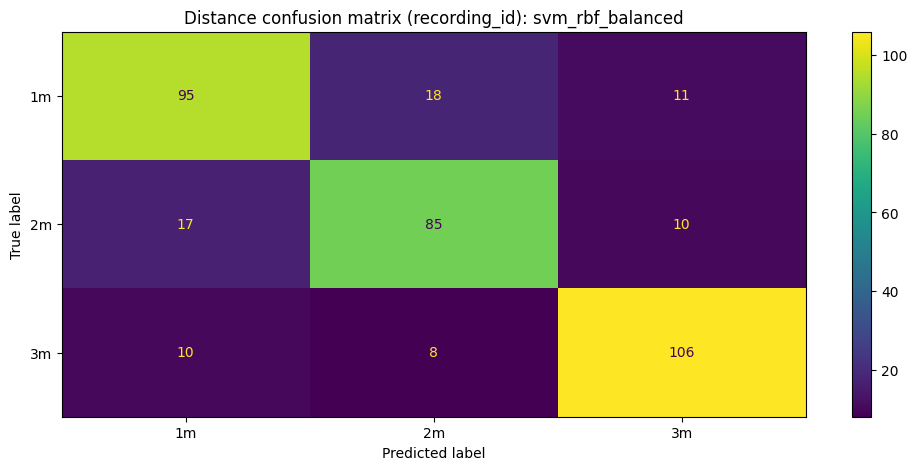

Distance split: person
Best model: logreg_balanced
Train balance: {1: 200, 2: 200, 3: 200}
Test balance : {1: 200, 2: 200, 3: 200}
              precision    recall  f1-score   support

          1m       0.51      0.32      0.39       200
          2m       0.55      0.56      0.55       200
          3m       0.53      0.72      0.61       200

    accuracy                           0.53       600
   macro avg       0.53      0.53      0.52       600
weighted avg       0.53      0.53      0.52       600



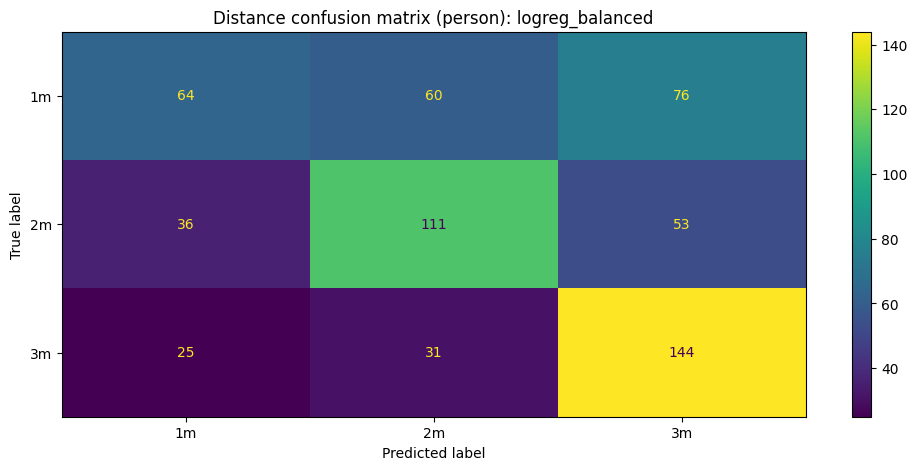

In [39]:
for split_group, result in distance_results.items():
    best_name = result["metrics"].iloc[0]["model"]
    best_model = result["fitted_models"][best_name]
    y_test = result["y_test"]
    y_pred = best_model.predict(result["X_test"])

    print("=" * 80)
    print(f"Distance split: {split_group}")
    print("Best model:", best_name)
    print("Train balance:", pd.Series(result["y_train"]).value_counts().sort_index().to_dict())
    print("Test balance :", pd.Series(y_test).value_counts().sort_index().to_dict())
    print(classification_report(
        y_test,
        y_pred,
        labels=DISTANCE_LABELS,
        target_names=DISTANCE_TARGET_NAMES,
        zero_division=0,
    ))

    cm = confusion_matrix(y_test, y_pred, labels=DISTANCE_LABELS)
    ConfusionMatrixDisplay(cm, display_labels=DISTANCE_TARGET_NAMES).plot(values_format="d")
    plt.title(f"Distance confusion matrix ({split_group}): {best_name}")
    plt.grid(False)
    plt.show()

Top distance RandomForest importances, split_group=recording_id


,feature,importance
271,motion__dev2_sc_energy_049,0.012171
254,motion__dev2_sc_energy_032,0.009877
270,motion__dev2_sc_energy_048,0.008766
74,motion__dev1_sc_energy_032,0.008143
234,motion__dev2_sc_energy_012,0.008113
73,motion__dev1_sc_energy_031,0.008064
71,motion__dev1_sc_energy_029,0.007855
72,motion__dev1_sc_energy_030,0.007597
91,motion__dev1_sc_energy_049,0.007284
413,motion__dev3_sc_energy_011,0.006993


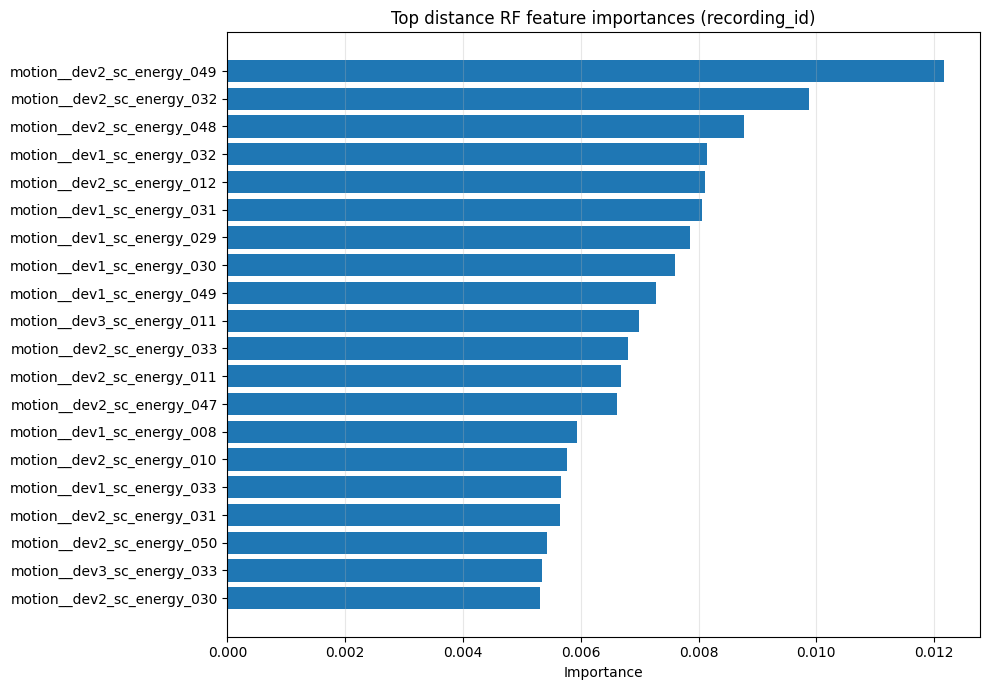

Top distance RandomForest importances, split_group=person


,feature,importance
235,motion__dev2_sc_energy_013,0.015273
272,motion__dev2_sc_energy_050,0.013385
435,motion__dev3_sc_energy_033,0.013149
575,motion__pair_dev2_dev3_absdiff_dt_mean,0.011478
576,motion__pair_dev2_dev3_absdiff_dt_std,0.011399
271,motion__dev2_sc_energy_049,0.011098
580,motion__pair_dev2_dev3_absdiff_dt_p90,0.010542
220,motion__dev2_motion_energy_p90,0.010538
208,motion__dev2_abs_dt_mean,0.010530
1,motion__global_dt_std,0.010216


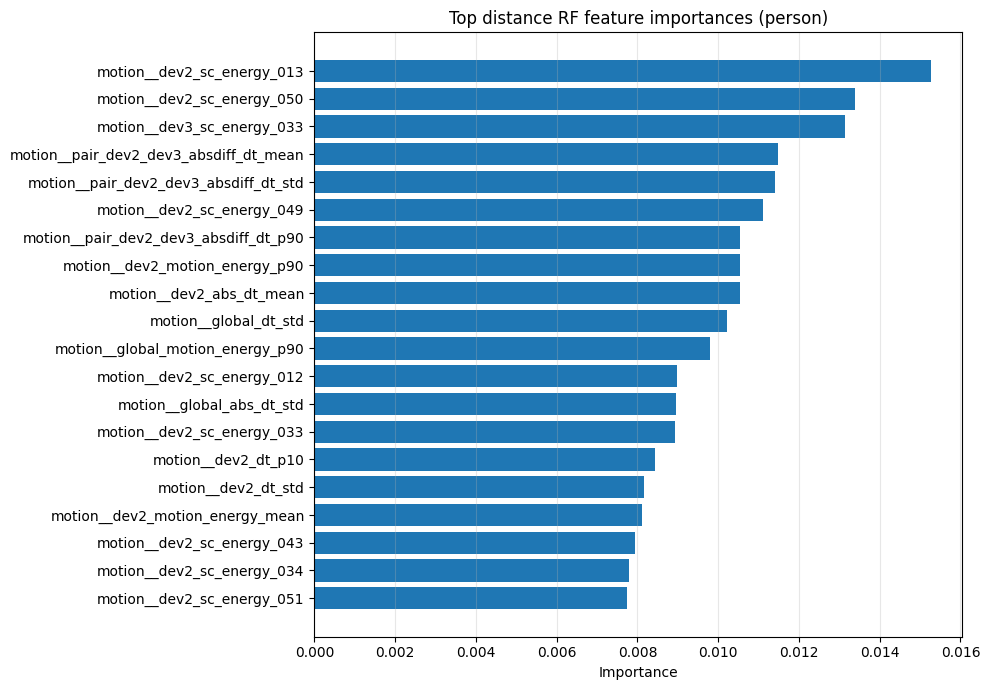

In [40]:
for split_group, result in distance_results.items():
    rf_distance = result["fitted_models"].get("random_forest_balanced")
    if rf_distance is None or not hasattr(rf_distance, "feature_importances_"):
        continue

    importance_df = pd.DataFrame({
        "feature": features_dist_ml.columns,
        "importance": rf_distance.feature_importances_,
    }).sort_values("importance", ascending=False)

    print(f"Top distance RandomForest importances, split_group={split_group}")
    display(importance_df.head(25))

    top = importance_df.head(20).iloc[::-1]
    plt.figure(figsize=(10, 7))
    plt.barh(top["feature"], top["importance"])
    plt.title(f"Top distance RF feature importances ({split_group})")
    plt.xlabel("Importance")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

## Notes

Для честной оценки расстояния важно сравнивать `recording_id` split и более строгий `person` split. Если качество на `person` split заметно ниже, модель частично опирается на индивидуальные/сессионные особенности, а не только на геометрию движения.